# Assignment on Variable Selection
nflcombine2021

In [29]:
# read data in 
df <-read.csv("C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/BDA Spring 26/Datasets/znflcombine2021.csv", header=TRUE)
head(df)
colnames(df)

,Ht,Wt,yd40,Vertical,Bench,BroadJump,Cone3,Shuttle,Draftedyes
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,-0.05226864,-0.8310177,-0.9919680,0.7947617,-0.1775535,0.5162616,-1.5108623,-1.2949906,1
2,-2.14835258,-1.2441244,-0.4241502,0.6746024,-1.2017744,-0.3326489,-0.6004284,-0.2640947,0
3,0.99577333,1.6911069,1.6263029,-0.8874689,1.1393018,-1.1815595,1.6366376,1.5915180,1
4,1.34791543,1.2780002,1.8471210,-1.1277876,1.2856191,-1.7121286,2.3129599,0.9729804,0
5,1.69586537,1.6911069,2.2887570,-1.0076283,-0.6165053,-1.1815595,-0.7044780,2.7048855,0
6,-1.79621048,-1.2223819,-0.8026954,0.5544431,-0.1775535,0.9407169,-0.4443541,-0.5527455,0


[1] "Ht"         "Wt"         "yd40"       "Vertical"   "Bench"     
[6] "BroadJump"  "Cone3"      "Shuttle"    "Draftedyes"

In [30]:
# nfl
# Stepwise Regression using AIC
# install.packages("MASS")
library(MASS)
step_model <- stepAIC(lm(Draftedyes ~ ., data = df), direction = "both", trace = FALSE)
# Print the selected variables
print(step_model$anova)

Stepwise Model Path 
Analysis of Deviance Table

Initial Model:
Draftedyes ~ Ht + Wt + yd40 + Vertical + Bench + BroadJump + 
    Cone3 + Shuttle

Final Model:
Draftedyes ~ Wt + yd40 + Cone3


         Step Df   Deviance Resid. Df Resid. Dev       AIC
1                                 258   48.26835 -438.6962
2  - Vertical  1 0.06585749       259   48.33420 -440.3322
3   - Shuttle  1 0.10060691       260   48.43481 -441.7770
4        - Ht  1 0.11008586       261   48.54490 -443.1708
5     - Bench  1 0.05452453       262   48.59942 -444.8711
6 - BroadJump  1 0.32655477       263   48.92598 -445.0830


# What to pick for Stepwise Regression using AIC
Predictors I would pick: 
Wt
yd40
Cone3

For a regression model to predict Draftedyes I would use the predictors Wt, yd40, Cone3. My model would be "Draftedyes ~ Wt + yd40 + Cone3".

,0,1,MeanDecreaseAccuracy,MeanDecreaseGini
Ht,0.9994553,6.221604,4.730660,10.64367
Wt,7.9569868,5.425602,11.415724,19.55672
yd40,2.1097116,10.721547,10.331736,17.94475
Vertical,4.0131213,6.452368,7.896023,13.62392
Bench,-1.2798636,10.190169,5.816705,15.62811
BroadJump,10.5594697,-4.012326,7.938856,14.19059
Cone3,4.3674210,5.073616,7.677842,16.82357
Shuttle,3.8574686,1.378580,4.367236,14.45082


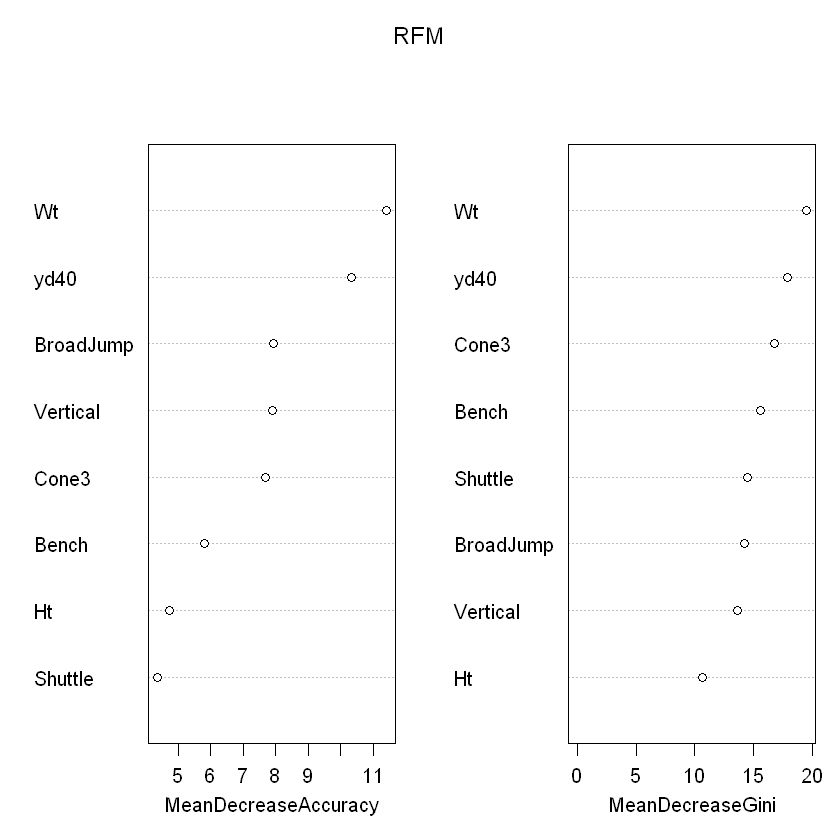

In [31]:
# Random Forest
library(randomForest)
df$Draftedyes<-factor(df$Draftedyes)
RFM=randomForest(Draftedyes ~.,data=df, importance=TRUE)
importance(RFM)
varImpPlot(RFM)

# What to pick for Random Forest
Predictors I would pick: 
Wt, yd40, Broadjump, Cone3

For a regression model to predict Draftedyes I would use the predictors Wt, yd40, BroadJump, Cone3. My model would be "Draftedyes ~ Wt + yd40 + BroadJump + Cone3". I chose this because the %IncMSE < 5. 

10 x 1 sparse Matrix of class "dgCMatrix"
                  seg72
intercept    1.36329588
(Intercept)  .         
Ht           0.03816811
Wt           0.26472550
yd40        -0.23852531
Vertical     .         
Bench        0.03886583
BroadJump    0.05558262
Cone3       -0.03811878
Shuttle     -0.03680288

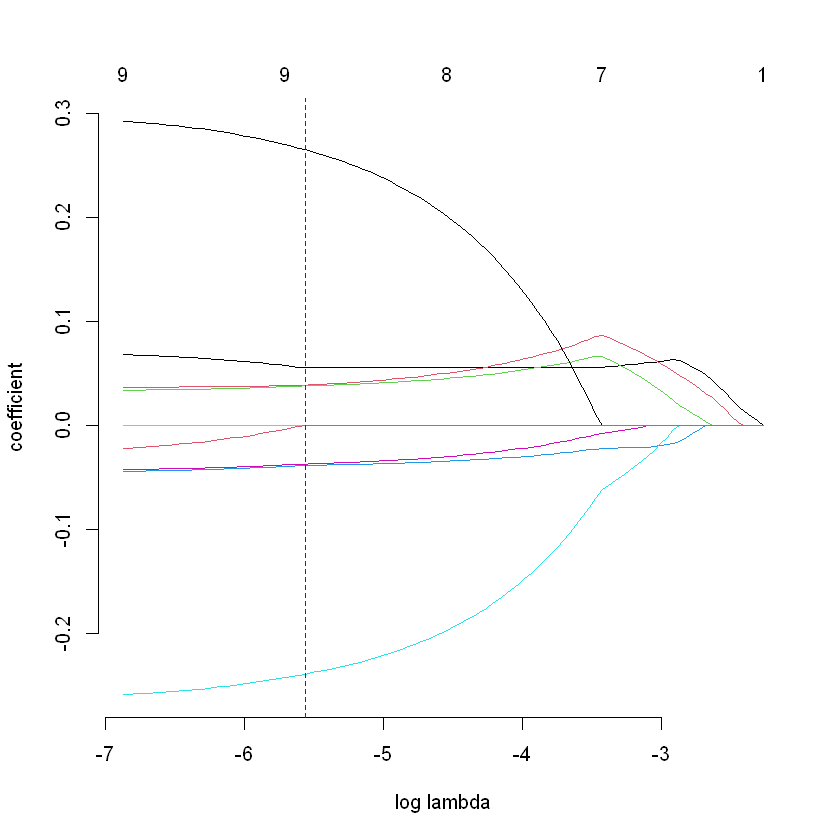

In [32]:
# Lasso Regression
# Note these variables are all on the same scale, so no standardization is needed.
# install.packages("gamlr")
library(gamlr)
modMat<-model.matrix(~Ht + Wt + yd40 + Vertical + Bench + BroadJump + 
    Cone3 + Shuttle, data=df)
fit<-gamlr(x=modMat,y=df$Draftedyes)
plot(fit)
coef(fit)

# What to pick for Lasso Regression
Predictors I would pick: 
Ht, Wt, yd40, Bench, BroadJump, Cone3, Shuttle. 

For a regression model to predict Draftedyes I would use the predictorsHt, Wt, yd40, Bench, BroadJump, Cone3, Shuttle. My model would be "Draftedyes ~ Ht+Wt+yd40+Bench+BroadJump+Cone3+Shuttle.". I chose this because the lasso regression chose these but would not take Vertical. 

# Models I would pick
I would choose stepwise model because of landing on 3 predictors. The lasso regression got better as all the other variables got removed. The random forest is the second best in my opinion, based off it being a percentage of it being removed and the increase of MSE%. 